In [4]:
import numpy as np
from matplotlib import pyplot as plt

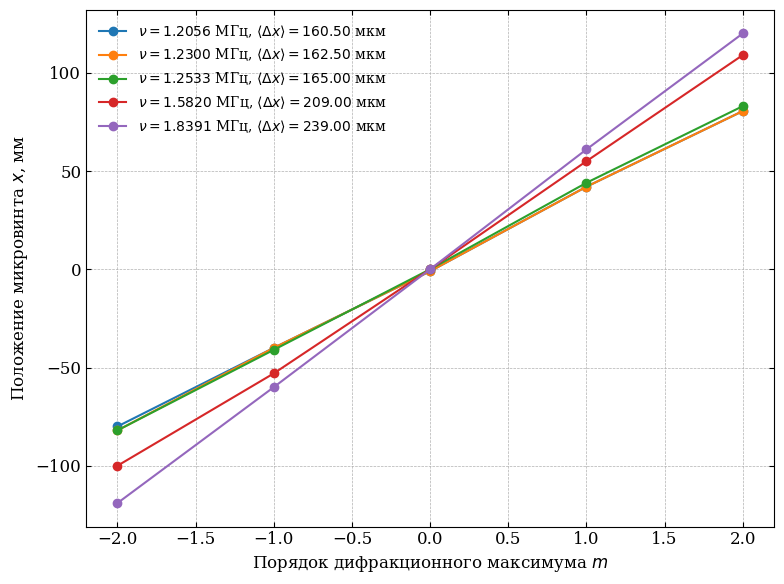

In [21]:

freqs = np.loadtxt("freq.txt")
maximums_data = np.loadtxt("maximums.txt")

orders = np.arange(-2, 3, 1)

# Настройки "ГОСТ-стиля"
plt.rcParams.update({
    "font.family": "serif",
    "font.size": 12,
    "axes.labelsize": 12,
    "legend.fontsize": 10,
    "xtick.direction": "in",
    "ytick.direction": "in",
})

plt.figure(figsize=(8, 6))

for freq, maximums in zip(freqs, maximums_data):
    mean_dx = np.mean(np.diff(maximums))
    
    plt.plot(
        orders,
        maximums,
        marker='o',
        linestyle='-',
        label=f"$\\nu = {freq:.4f}$ МГц, $\\langle \\Delta x \\rangle = {4*mean_dx:.2f}$ мкм"
    )

# Подписи осей
plt.xlabel("Порядок дифракционного максимума $m$")
plt.ylabel("Положение микровинта $x$, мм")

# Сетка (тонкая, как обычно требуют)
plt.grid(True, linestyle='--', linewidth=0.5)

# Деления с обеих сторон
plt.tick_params(top=True, right=True)

# Легенда без рамки
plt.legend(frameon=False)

# Подгонка полей
plt.tight_layout()

plt.savefig("graph1.pdf")

In [48]:
data_x = []
data_y = []
# Константы
lam = 520e-9          # длина волны, м
dlam = 10e-9          # погрешность, м

F2 = 0.30             # фокусное расстояние, м

dnu = 1e3             # погрешность частоты, Гц
dh = 8e-6             # погрешность h, м

for nu, x in zip(freqs * 10**6, maximums_data):
    dx = (x[-1] - x[0]) / (len(x) - 1) * 4 * 10**-6  # среднее расстояние между максимумами м
    
    v = lam * F2 * nu / dx
    
    sigma_v = v * np.sqrt(
        (dlam / lam)**2 +
        (dnu / (nu*10**6))**2 +
        (dh / dx)**2
    )
    data_x.append(nu)
    data_y.append(v)
    print(f"ν = {nu/1e6:.4f} МГц | v = {v:.1f} м/с ± {sigma_v:.2f} м/с")



ν = 1.2056 МГц | v = 1171.8 м/с ± 62.60 м/с
ν = 1.2300 МГц | v = 1180.8 м/с ± 62.41 м/с
ν = 1.2533 МГц | v = 1184.9 м/с ± 61.81 м/с
ν = 1.5820 МГц | v = 1180.8 м/с ± 50.58 м/с
ν = 1.8391 МГц | v = 1200.4 м/с ± 46.34 м/с
